In [81]:
import numpy as np
import matplotlib.pyplot as pl
import finufft

In [34]:
sampling_freq = 2048
t = np.arange(0, 1e4, 1/sampling_freq)

f0 = 20
fdot = 1e-3
phase = f0*t + 1/2*fdot*t**2
signal = np.real(np.exp(1j*phase))

## Strobo

In [49]:
def strobo(new_t, data, f_ratio):
    f_new = sampling_freq/f_ratio
    new_t *= f_new #changes the frequency to the new downsampled frequency (approximately, not exactly)
    floor_t = np.floor(new_t) #For some reason floor works better than round. Take it to the nearest time index which are integers
    idx = np.nonzero(np.diff(floor_t)) #The step that downsamples

    resampled_data = data[idx]
    resampled_time = (new_t[idx]-new_t[0])/f_new
    return (resampled_data, resampled_time)

In [59]:
new_t = 1/(2*np.pi)*(t+1/(2*f0)*fdot*t**2)
resampled_data, resampled_time = strobo(new_t, signal, 8)
fft_power = abs(np.fft.fftshift(np.fft.fft(resampled_data)))**2
fft_freqs = np.fft.fftshift(np.fft.fftfreq(len(resampled_time), np.diff(resampled_time)[0]))

In [66]:
fft_freqs1 = np.fft.fftshift(np.fft.fftfreq(len(resampled_time)//2, np.diff(resampled_time)[0]))
fft_power1 = abs(np.fft.fftshift(np.fft.fft(resampled_data[:len(resampled_data)//2])))**2
fft_power2 = abs(np.fft.fftshift(np.fft.fft(resampled_data[len(resampled_data)//2:-1])))**2

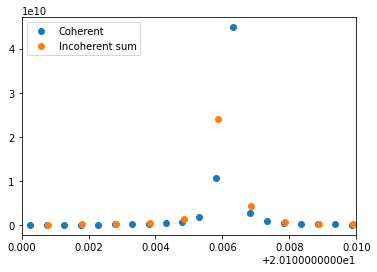

In [75]:
pl.plot(fft_freqs, fft_power, 'o', label='Coherent')
pl.plot(fft_freqs1, fft_power1+fft_power2, 'o', label = "Incoherent sum")
pl.xlim(20.1, 20.11)
pl.legend(loc=2)

In [148]:
np.max(fft_power) / np.max(fft_power1+fft_power2)

1.8645575822668867

## NUFFT

In [141]:
def nufft(new_t, data, bin_no=len(new_t)):
    bins = np.arange(bin_no) - bin_no//2
    
    tau = new_t
    scale = (2*np.pi)/(tau[-1]-tau[0])
    tau *= scale
    start_diff = -np.pi-tau[0]
    tau += start_diff
    nufft_amp = finufft.nufft1d1(tau, data.astype(complex), bin_no)
    nufft_freq = -bins*scale/(2*np.pi)
    nufft_weights = nufft_amp
    return nufft_freq, nufft_weights

In [149]:
np.power(2, 1/2)

1.4142135623730951

In [142]:
new_t = 1/(2*np.pi)*(t+1/(2*f0)*fdot*t**2)
nufft_freq, nufft_weights = nufft(new_t, signal)
new_t = 1/(2*np.pi)*(t+1/(2*f0)*fdot*t**2)
nufft_freq1, nufft_weights1 = nufft(new_t[:len(new_t)//2], signal[:len(new_t)//2])
new_t = 1/(2*np.pi)*(t+1/(2*f0)*fdot*t**2)
nufft_freq2, nufft_weights2 = nufft(new_t[len(new_t)//2:], signal[len(new_t)//2:])

(19.99, 20.01)

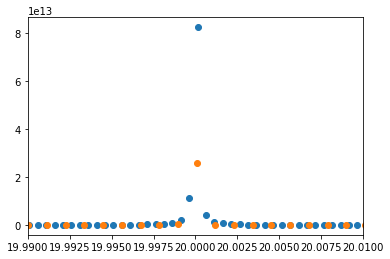

In [143]:
pl.plot(nufft_freq, abs(nufft_weights)**2, 'o')
pl.plot(nufft_freq1, abs(nufft_weights1+nufft_weights2)**2, 'o')
pl.xlim(19.99, 20.01)

In [144]:
np.max(abs(nufft_weights)**2) / np.max(abs(nufft_weights1+nufft_weights2)**2)

3.1990628986507543